In [1]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

model = joblib.load('../models/churn_model.pkl')
feature_columns = joblib.load('../models/feature_columns.pkl')

assert list(X_test.columns) == feature_columns, "Column mismatch!"

E:\ibrahim\Portfolio Projects\customer-churn-prediction\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print("SHAP values shape:", shap_values.shape)

SHAP values shape: (1409, 36)


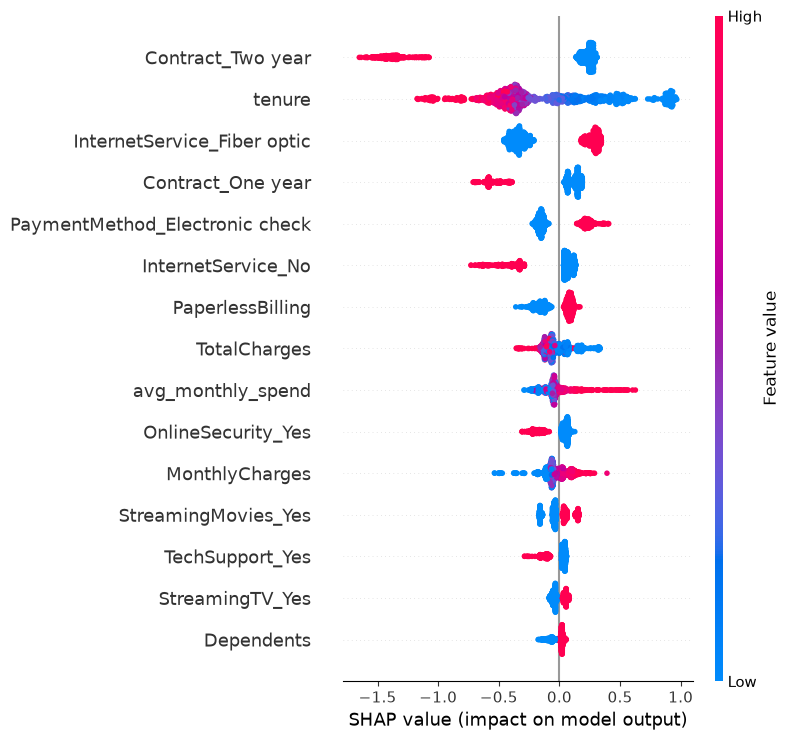

In [3]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, show=False, max_display=15)
plt.tight_layout()
plt.savefig('../reports/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

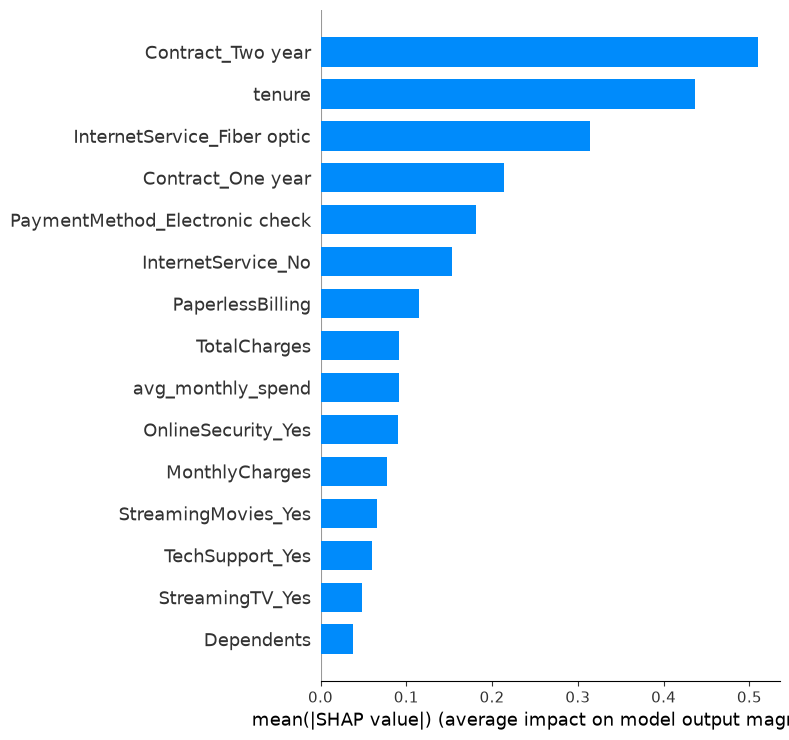

In [4]:
plt.figure(figsize=(9, 7))
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False, max_display=15)
plt.tight_layout()
plt.savefig('../reports/shap_importance_bar.png', dpi=150, bbox_inches='tight')
plt.show()

Customer index: 1
Predicted churn probability: 84.32%
Actual outcome: Did not churn


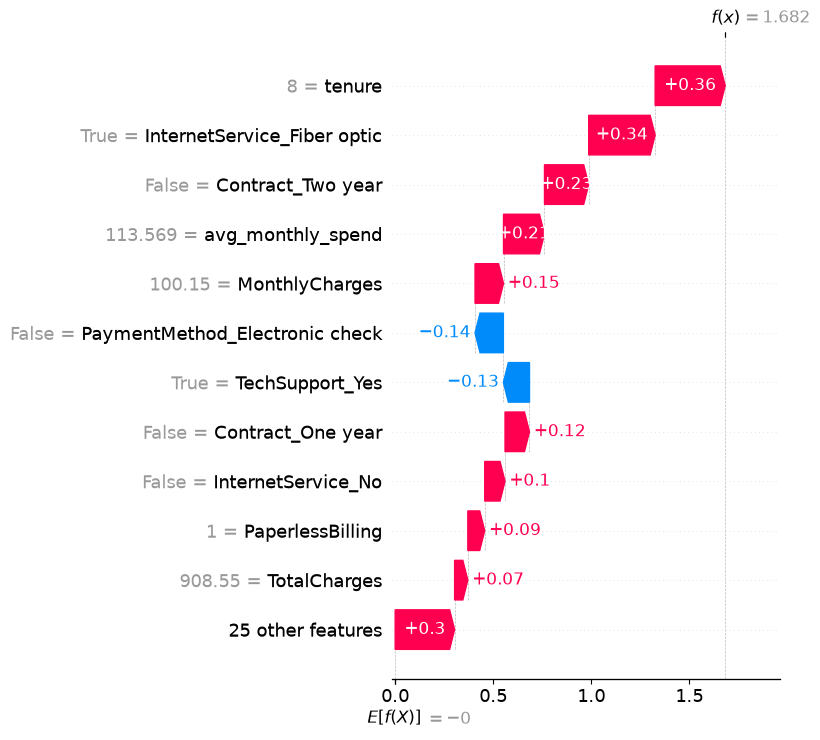

In [5]:
sample_idx = 0
y_pred_proba = model.predict_proba(X_test)[:, 1]
churn_candidates = np.where(y_pred_proba > 0.7)[0]

if len(churn_candidates) > 0:
    sample_idx = churn_candidates[0]

print(f"Customer index: {sample_idx}")
print(f"Predicted churn probability: {y_pred_proba[sample_idx]:.2%}")
print(f"Actual outcome: {'Churned' if y_test.iloc[sample_idx] == 1 else 'Did not churn'}")

shap_exp = shap.Explanation(
    values=shap_values[sample_idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[sample_idx].values,
    feature_names=feature_columns
)

plt.figure(figsize=(10, 7))
shap.plots.waterfall(shap_exp, max_display=12, show=False)
plt.tight_layout()
plt.savefig('../reports/shap_waterfall_example.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False)

feature_importance.to_csv('../reports/feature_importance.csv', index=False)
print(feature_importance.head(10).to_string(index=False))

                       feature  mean_abs_shap
             Contract_Two year       0.510137
                        tenure       0.436871
   InternetService_Fiber optic       0.313884
             Contract_One year       0.213942
PaymentMethod_Electronic check       0.181629
            InternetService_No       0.153299
              PaperlessBilling       0.114575
                  TotalCharges       0.091518
             avg_monthly_spend       0.091238
            OnlineSecurity_Yes       0.089775
